Wymiary zbioru danych: (156, 30)
              PSU          O2   SecchDisc       temp.          SS        chla  \
count  156.000000  156.000000  156.000000  156.000000  156.000000  156.000000   
mean     3.356954   10.180705    0.376026   17.350000   86.937115   58.011474   
std      0.758865    1.078504    0.115147    3.122251   35.506823   33.122486   
min      1.400000    7.620000    0.200000   10.600000   29.000000    0.000000   
25%      2.800000    9.367500    0.300000   16.200000   60.000000   32.760000   
50%      3.379124    9.955000    0.350000   17.900000   80.000000   53.515000   
75%      3.957258   10.890000    0.450000   20.100000  111.562500   81.910000   
max      4.600000   12.890000    0.700000   20.700000  217.500000  170.370000   

              SRP         DOP          PP          TP  ...         DOC  \
count  156.000000  156.000000  156.000000  156.000000  ...  156.000000   
mean    15.034615   22.421154  134.547436  172.003205  ...    8.206301   
std     11.8423

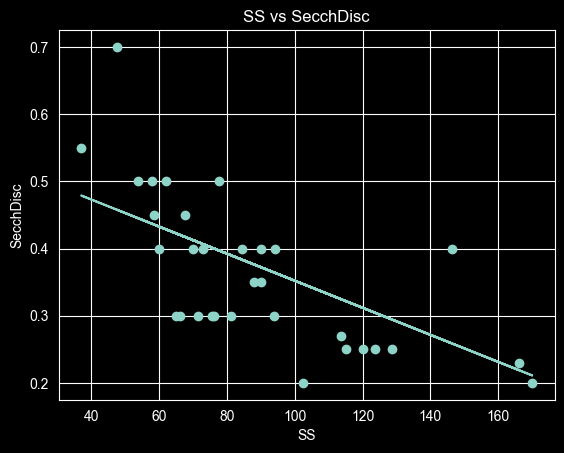


MODEL 2: TP -> chla
Intercept (b): 23.12475644005572
Slope (m): 0.20154582462743886

Błędy modelu 2:
MAE: 27.952481356534676
MSE: 1171.6165411922939
RMSE: 34.228884603391535


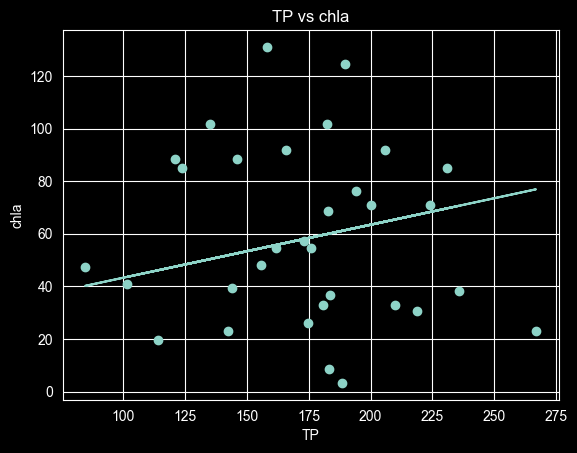

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Wczytanie danych
dataset = pd.read_csv("data/Kruk_VLagun_156.csv")
dataset.columns = dataset.columns.str.strip()

print("Wymiary zbioru danych:", dataset.shape)
print(dataset.describe())

# MODEL 1: Przewidywanie SecchDisc na podstawie SS
X1 = dataset[['SS']]
y1 = dataset['SecchDisc']

# podziel na dane treningowe (80%) i testowe (20%)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=0
)
# regresja liniowa, trenowanie
regressor1 = LinearRegression()
regressor1.fit(X1_train, y1_train)

print("\nMODEL 1: SS -> SecchDisc")
print("Intercept (b):", regressor1.intercept_)
print("Slope (m):", regressor1.coef_[0])

y1_pred = regressor1.predict(X1_test)

# błedy pomariaru
print("\nBłędy modelu 1:")
print("MAE:", metrics.mean_absolute_error(y1_test, y1_pred))
print("MSE:", metrics.mean_squared_error(y1_test, y1_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y1_test, y1_pred)))

# Wykres
plt.figure()
plt.scatter(X1_test, y1_test)
plt.plot(X1_test, y1_pred)
plt.title("SS vs SecchDisc")
plt.xlabel("SS")
plt.ylabel("SecchDisc")
plt.show()

# MODEL 2: Przewidywanie chla na podstawie TP
X2 = dataset[['TP']]
y2 = dataset['chla']

# 80 do 20
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=0
)

regressor2 = LinearRegression()
regressor2.fit(X2_train, y2_train)

print("\nMODEL 2: TP -> chla")
print("Intercept (b):", regressor2.intercept_)
print("Slope (m):", regressor2.coef_[0])

y2_pred = regressor2.predict(X2_test)

print("\nBłędy modelu 2:")
print("MAE:", metrics.mean_absolute_error(y2_test, y2_pred))
print("MSE:", metrics.mean_squared_error(y2_test, y2_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y2_test, y2_pred)))

# Wykres
plt.figure()
plt.scatter(X2_test, y2_test)
plt.plot(X2_test, y2_pred)
plt.title("TP vs chla")
plt.xlabel("TP")
plt.ylabel("chla")
plt.show()